<a href="https://colab.research.google.com/github/shadmanr1/Milestone_1/blob/main/Week_11_Notebook_Shadman_Raakin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

#Dataset: Movie Box office (2000-2024)
General overview of the dataset is that it provides a detailed analysis of global box office performance from 2000 to 2024. It includes information on movies released during this period, covering key metrics such as release dates, genres, production budgets, worldwide gross, and more. The dataset aims to assist researchers, data scientists, and movie enthusiasts in exploring trends in the film industry, analyzing profitability, and understanding audience preferences over the years. https://www.kaggle.com/datasets/aditya126/movies-box-office-dataset-2000-2024?select=enhanced_box_office_data%282000-2024%29u.csv

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving enhanced_box_office_data(2000-2024)u.csv to enhanced_box_office_data(2000-2024)u.csv


In [ ]:
df = pd.read_csv("enhanced_box_office_data(2000-2024)u.csv")
# Convert rating from "6.126/10" to 6.126
df["Rating_num"] = pd.to_numeric(df["Rating"].astype(str).str.extract(r"([0-9.]+)")[0],errors="coerce")
# Log-transform highly skewed variables
df["Log_Vote_Count"] = np.log1p(df["Vote_Count"])
df["Log_Worldwide"] = np.log1p(df["$Worldwide"])

In [ ]:
features = [
    "Year",
    "Rating_num",
    "Log_Vote_Count",
    "Log_Worldwide",
    "Domestic %"
]

X = df[features].copy()

# Median imputation
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

Using K distance plot to choose the eps

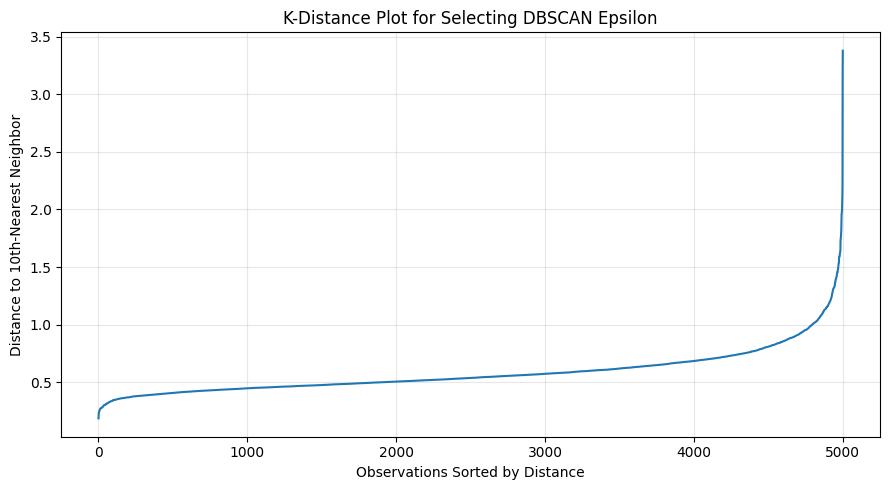

In [ ]:
min_samples = 10

neighbors = NearestNeighbors(
    n_neighbors=min_samples,
    metric="euclidean"
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

# Distance to each observation's tenth-nearest neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))

plt.plot(k_distances)

plt.xlabel("Observations Sorted by Distance")
plt.ylabel("Distance to 10th-Nearest Neighbor")
plt.title("K-Distance Plot for Selecting DBSCAN Epsilon")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Comparing DBSCAN parameters

In [ ]:
dbscan_results = []

for min_samples in [10, 20, 30, 50]:
    for eps in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean"
        )

        labels = dbscan.fit_predict(X_scaled)

        non_noise = labels != -1

        number_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        noise_percent = (
            np.mean(labels == -1) * 100
        )

        if number_clusters >= 2:
            score = silhouette_score(
                X_scaled[non_noise],
                labels[non_noise]
            )
        else:
            score = np.nan

        dbscan_results.append({
            "Epsilon": eps,
            "Min_Samples": min_samples,
            "Clusters": number_clusters,
            "Noise_Percent": noise_percent,
            "Silhouette": score
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

print(
    dbscan_results_df.sort_values(
        "Silhouette",
        ascending=False
    ).head(15)
)

    Epsilon  Min_Samples  Clusters  Noise_Percent  Silhouette
2       0.7           10         2           6.94    0.667805
3       0.8           10         2           3.74    0.657750
4       0.9           10         2           1.98    0.651778
5       1.0           10         2           1.10    0.648931
19      0.6           50         4          78.48    0.399817
20      0.7           50         2          37.58    0.377753
13      0.6           30         3          46.80    0.332970
1       0.6           10         2          14.92    0.279557
6       0.5           20         4          68.96    0.258894
12      0.5           30         6          87.24    0.174032
7       0.6           20         3          29.98    0.031764
0       0.5           10         7          35.58   -0.158393
8       0.7           20         1          13.10         NaN
9       0.8           20         1           6.98         NaN
10      0.9           20         1           4.08         NaN


The combination eps=0.7 and min_samples=10 produces the highest useful silhouette score while retaining most observations.

Fitting DBSCAN

In [ ]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=10,
    metric="euclidean"
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1     347
 0    4641
 1      12
Name: count, dtype: int64


A label of -1 means that DBSCAN considered the observation noise.

Examining the results:

In [ ]:
dbscan_summary = df.groupby("DBSCAN_Cluster").agg(
    Number_of_Movies=("DBSCAN_Cluster", "size"),
    Average_Year=("Year", "mean"),
    Average_Rating=("Rating_num", "mean"),
    Median_Votes=("Vote_Count", "median"),
    Median_Worldwide_Revenue=("$Worldwide", "median"),
    Average_Domestic_Percent=("Domestic %", "mean")
).round(2)

print(dbscan_summary)

                Number_of_Movies  Average_Year  Average_Rating  Median_Votes  \
DBSCAN_Cluster                                                                 
-1                           347       2012.94            5.96          88.0   
 0                          4641       2011.90            6.57        1168.0   
 1                            12       2023.00            0.00           0.0   

                Median_Worldwide_Revenue  Average_Domestic_Percent  
DBSCAN_Cluster                                                      
-1                            25331842.0                     42.38  
 0                            50576805.0                     35.34  
 1                            10175474.0                      0.00  


The small second cluster primarily contains movies with rating and vote-count values of zero. Therefore, its separation may reflect missing rather than a meaningful movie segment.
This explains the high silhouette score: DBSCAN separated a tiny, distant group from the main dataset. A high silhouette score does not automatically mean the solution is substantively useful.

Looking at noise observations:

In [ ]:
noise_movies = df[df["DBSCAN_Cluster"] == -1][[
    "Release Group",
    "Year",
    "$Worldwide",
    "Rating_num",
    "Vote_Count",
    "Domestic %"]]

print(noise_movies.head(20))

                            Release Group  Year   $Worldwide  Rating_num  \
40                                The Kid  2000  110317580.0       8.170   
86                     Dancer in the Dark  2000   40031879.0       7.875   
93   The Adventures of Rocky & Bullwinkle  2000   35134820.0       4.100   
94                        American Psycho  2000   34266564.0       7.401   
101                     Battlefield Earth  2000   29725663.0       3.300   
106      Cirque du Soleil: Journey of Man  2000   27538359.0       7.000   
114             Michael Jordan to the Max  2000   21268532.0       7.323   
122                            CyberWorld  2000   16653900.0       6.200   
130                   I Dreamed of Africa  2000   14400327.0       5.500   
133                              Solarmax  2000   13400161.0       6.700   
138                     Drunken Master II  2000   11555430.0       7.420   
145                   The Virgin Suicides  2000   10409377.0       7.119   
154         

DBSCAN It can identify unusual movies that have rare combinations of:

Revenue,
Rating,
Audience engagement,
Release year,
Domestic/international revenue distribution

Hierarchial Clustering

In [ ]:
hac_results = []

for linkage_method in [
    "ward",
    "complete",
    "average",
    "single"
]:
    for k in range(2, 7):

        hac = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage_method,
            metric="euclidean"
        )

        labels = hac.fit_predict(X_scaled)

        score = silhouette_score(
            X_scaled,
            labels
        )

        hac_results.append({
            "Linkage": linkage_method,
            "Clusters": k,
            "Silhouette": score
        })

hac_results_df = pd.DataFrame(hac_results)

print(
    hac_results_df.sort_values(
        "Silhouette",
        ascending=False
    )
)

     Linkage  Clusters  Silhouette
10   average         2    0.639245
5   complete         2    0.639245
17    single         4    0.525590
18    single         5    0.524721
15    single         2    0.516183
16    single         3    0.516179
11   average         3    0.295607
0       ward         2    0.271944
12   average         4    0.243194
13   average         5    0.242768
1       ward         3    0.213046
2       ward         4    0.192970
6   complete         3    0.173068
4       ward         6    0.167911
19    single         6    0.160391
3       ward         5    0.157036
7   complete         4    0.135328
8   complete         5    0.135030
14   average         6    0.127328
9   complete         6    0.125062


From results, complete or average linkage with two clusters seems best because the silhouette score is 0.639. However, the two complete-linkage clusters contain:

4,975 movies
25 movies

The smaller cluster consists mainly of movies with missing or zero ratings and vote counts. Complete linkage is therefore detecting an outlier group rather than producing useful market segments.

Single linkage has a similar problem. It can create a chaining effect in which most observations join one large cluster while a few isolated points form extremely small clusters.

Using ward linakge

In [ ]:
ward_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward",
    metric="euclidean"
)

df["HAC_Cluster"] = ward_model.fit_predict(X_scaled)

summarize the groups:

In [ ]:
hac_summary = df.groupby("HAC_Cluster").agg(
    Number_of_Movies=("HAC_Cluster", "size"),
    Average_Year=("Year", "mean"),
    Average_Rating=("Rating_num", "mean"),
    Median_Votes=("Vote_Count", "median"),
    Median_Worldwide_Revenue=("$Worldwide", "median"),
    Average_Domestic_Percent=("Domestic %", "mean")
).round(2)

print(hac_summary)

             Number_of_Movies  Average_Year  Average_Rating  Median_Votes  \
HAC_Cluster                                                                 
0                        3089       2010.51            6.52        2115.0   
1                        1911       2014.41            6.49         153.0   

             Median_Worldwide_Revenue  Average_Domestic_Percent  
HAC_Cluster                                                      
0                          82169884.0                     55.39  
1                          27720972.0                      3.99  


Cluster 0: higher-engagement domestic releases

This cluster has:

Higher median worldwide revenue,
Much higher audience vote counts,
A large domestic revenue share,
A somewhat earlier average release year.

These appear to be movies with greater exposure in the domestic market and stronger audience engagement.

Cluster 1: lower-engagement international releases

This cluster has:

Lower median worldwide revenue,
Far fewer audience votes,
Almost no domestic revenue,
A later average release year,

These appear to include movies that made most of their revenue internationally and received limited domestic exposure.

Ratings are nearly identical between the clusters. The segmentation is mostly driven by revenue, engagement, and domestic-market presence rather than critical or audience ratings.

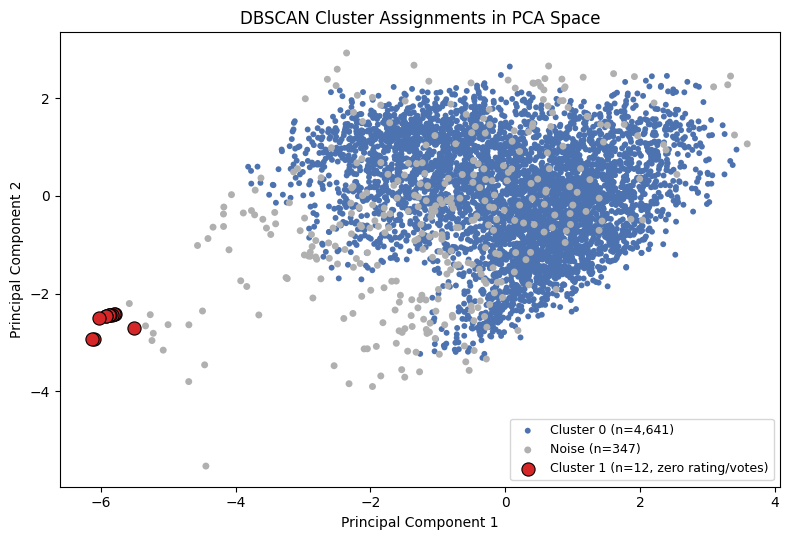

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

label_map = {0: "Cluster 0 (n=4,641)", 1: "Cluster 1 (n=12, zero rating/votes)", -1: "Noise (n=347)"}
df["Cluster_Label"] = df["DBSCAN_Cluster"].map(label_map)

plt.figure(figsize=(8, 5.5))

order = ["Cluster 0 (n=4,641)", "Noise (n=347)", "Cluster 1 (n=12, zero rating/votes)"]
palette = {"Cluster 0 (n=4,641)": "#4C72B0", "Noise (n=347)": "#B0B0B0", "Cluster 1 (n=12, zero rating/votes)": "#D62728"}
sizes = {"Cluster 0 (n=4,641)": 18, "Noise (n=347)": 25, "Cluster 1 (n=12, zero rating/votes)": 90}

for lab in order:
    sub = df[df["Cluster_Label"] == lab]
    plt.scatter(sub["PC1"], sub["PC2"], s=sizes[lab], c=palette[lab], label=lab,
                edgecolors="black" if lab.startswith("Cluster 1") else "none", linewidths=0.8)

plt.title("DBSCAN Cluster Assignments in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

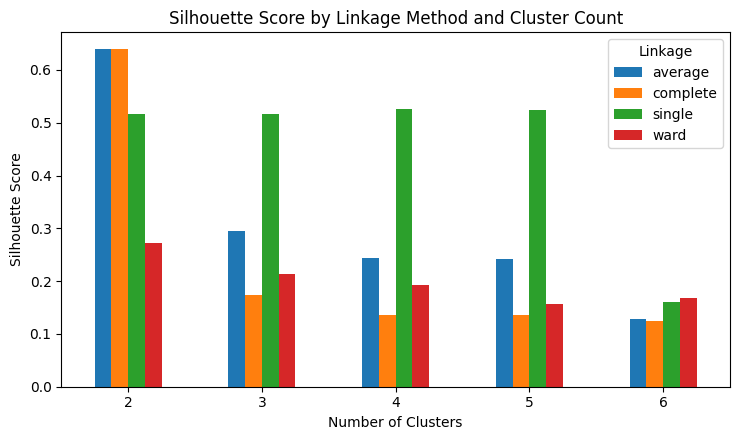

In [ ]:
pivot = hac_results_df.pivot(index="Clusters", columns="Linkage", values="Silhouette")

pivot.plot(kind="bar", figsize=(7.5, 4.5))
plt.title("Silhouette Score by Linkage Method and Cluster Count")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=0)
plt.legend(title="Linkage")
plt.tight_layout()
plt.show()

Making a dendogram

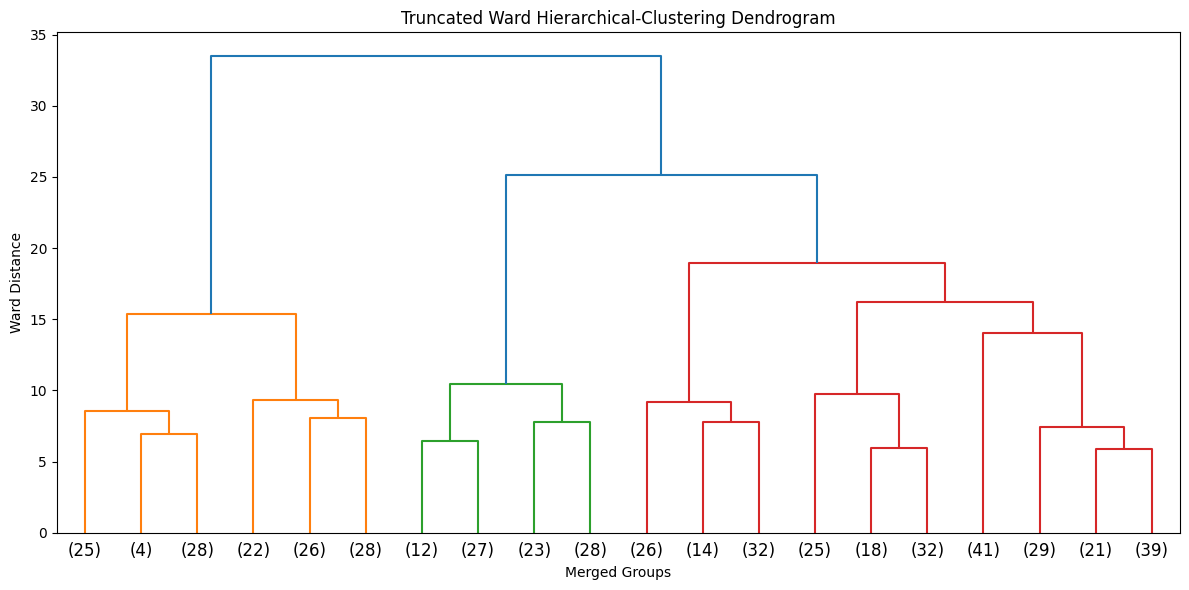

In [ ]:
rng = np.random.default_rng(42)

sample_indices = rng.choice(
    len(X_scaled),
    size=500,
    replace=False
)

X_sample = X_scaled[sample_indices]

linkage_matrix = linkage(
    X_sample,
    method="ward",
    metric="euclidean"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=20,
    show_leaf_counts=True
)

plt.title("Truncated Ward Hierarchical-Clustering Dendrogram")
plt.xlabel("Merged Groups")
plt.ylabel("Ward Distance")
plt.tight_layout()
plt.show()

Overall: DBSCAN does not reveal several strong density-based movie segments in this feature space. Instead, it identifies one dominant movie group, a set of 347 unusual observations, and a tiny cluster of 12 movies with little rating or vote information. Its strongest contribution is therefore anomaly detection rather than market segmentation.

Hierarchical clustering with Ward linkage produces a more meaningful two-cluster solution. It separates higher-revenue, domestically concentrated, highly engaged movies from lower-revenue movies with limited domestic exposure and fewer audience votes. Its silhouette score of 0.272 is modest, indicating overlap, but the groups are balanced and substantively interpretable.
